In [ ]:
pip install asammdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.3/920.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.6/328.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.9/258.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.2 MB/s eta 0:00:00


**Modifier le code pour l'exécuter sous Jupyter Notebook ou autre, ne fonctionne plus sur Google Collab actuellement**

In [ ]:
import os
import numpy as np
from scipy.signal import welch, butter, sosfiltfilt, freqs
import matplotlib.pyplot as plt
#from scipy.io.wavfile import write
#from scipy.signal import periodogram, spectrogram, oaconvolve
from asammdf import MDF

import librosa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.chdir('/content/drive/My Drive/OneDrive-Bibliothèquespartagées-SNCF/TLI - Données SIM GrpO365 - Huddersfield - Campagne de mesure juin 2024')

l_path= [
         "RecordFile_24-06-26_16_35_56_492.mf4", # 40 km/h
         "RecordFile_24-06-26_16_43_59_644.mf4", # 80 km/h
         "RecordFile_24-06-26_17_02_13_620.mf4", # 120 km/h
         "RecordFile_24-06-26_17_08_57_704.mf4", # 160 km/h
         "RecordFile_24-06-25_09_38_22_758.mf4",
         ]

path = l_path[2] # Selection of the data to read
name = path.split('.')[0]

data = MDF(path, memory='low')

print(data.info())

{'version': '4.11', 'program': 'Sefram_D', 'comment': '<HDcomment>\n <TX/>\n <common_properties>\n  <e name="author"/>\n  <e name="department"/>\n  <e name="project"/>\n  <e name="subject"/>\n  <e name="timezone">Europe/Paris</e>\n </common_properties>\n <time_source>internal clock</time_source>\n</HDcomment>', 'groups': 1, 'group 0': {'cycles': 32900557, 'comment': 'Channel group for Freq (freq 100000)', 'channels count': 14, 'channel 0': 'name="Time" type=VIRTUAL MASTER', 'channel 1': 'name="3A_X" type=VALUE', 'channel 2': 'name="Harold" type=VALUE', 'channel 3': 'name="Son_4" type=VALUE', 'channel 4': 'name="3A_Y" type=VALUE', 'channel 5': 'name="3A_Z" type=VALUE', 'channel 6': 'name="Acc_1" type=VALUE', 'channel 7': 'name="Son_2" type=VALUE', 'channel 8': 'name="Son_3" type=VALUE', 'channel 9': 'name="Son_1" type=VALUE', 'channel 10': 'name="Acc_4" type=VALUE', 'channel 11': 'name="Reflex" type=VALUE', 'channel 12': 'name="Acc_3" type=VALUE', 'channel 13': 'name="Acc_2" type=VALUE'

# **Acc_1**

In [ ]:
id_channel = 4 # selection of the channel

l_signal_id = ['Son_1', # 0
               'Son_2', # 1
               'Son_3', # 2
               'Son_4', # 3
               'Acc_1', # 4
               'Acc_2', # 5
               'Acc_3', # 6
               'Acc_4', # 7
               '3A_X', # 8
               '3A_Y', # 9
               '3A_Z', # 10
               'Reflex', # 11
               'Harold'] # 12

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

**Modifier ce code selon la longueur d'un segment à déterminer manuellement, semble être différent selon les environnement d'exécution et les mises à jour**

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20648879, 7),
    (20648880, 23229989, 8),
    (23229990, 25811099, 9),
    (25811100, 28392209, 10),
    (28392210, 30973319, 11),
    (30973320, 32900556, 12)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés


In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


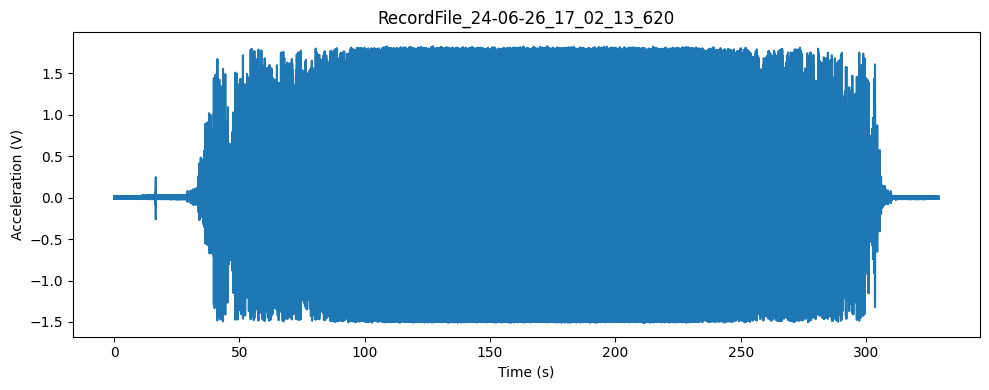

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

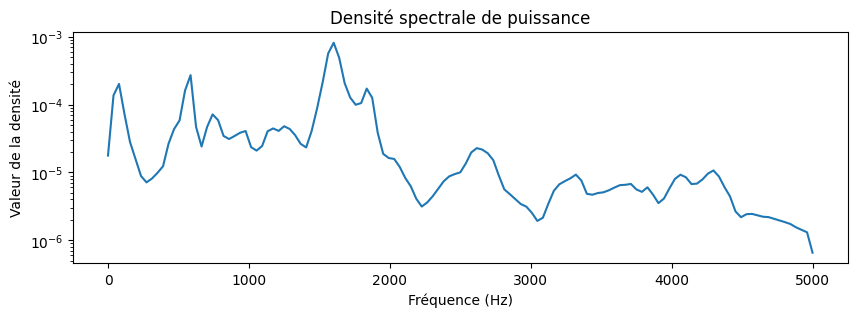

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

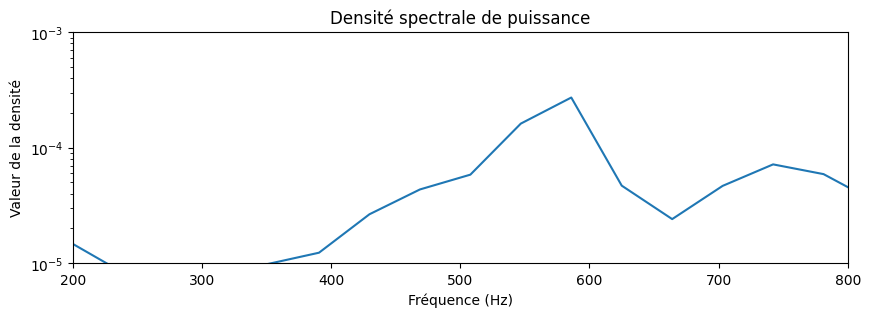

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(200, 800)
plt.ylim(1e-5, 1e-3)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
from scipy.signal import filtfilt

# Définir un filtre passe-bande
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band', analog=False)
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data)

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 25   # Fréquence basse (Hz)
highcut = 125  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

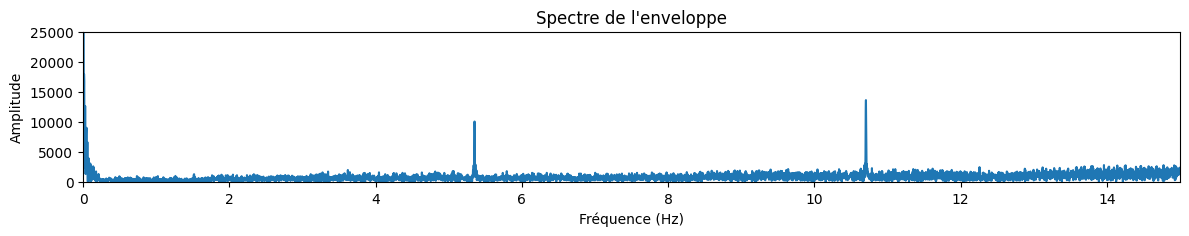

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

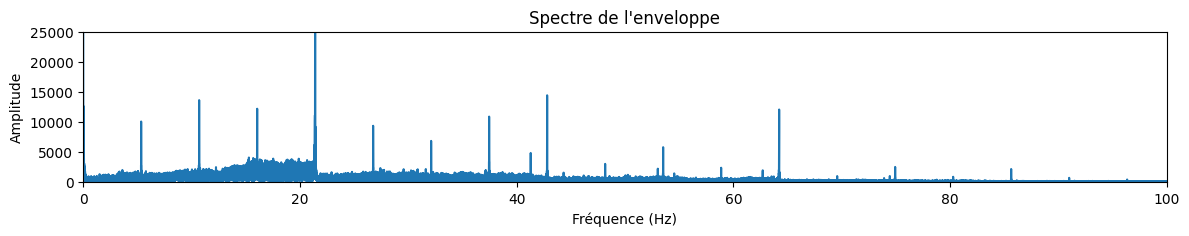

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 550   # Fréquence basse (Hz)
highcut = 600  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

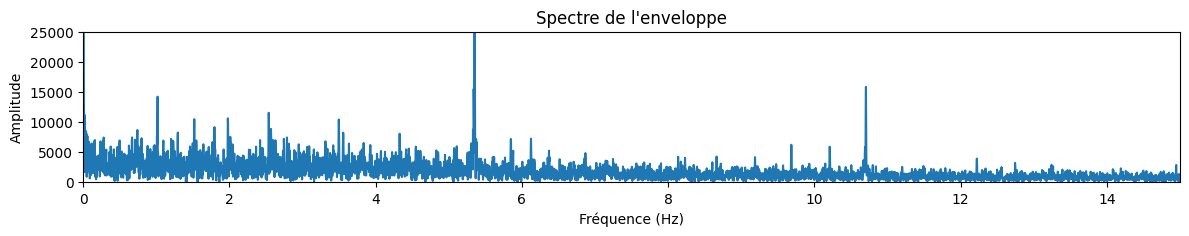

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

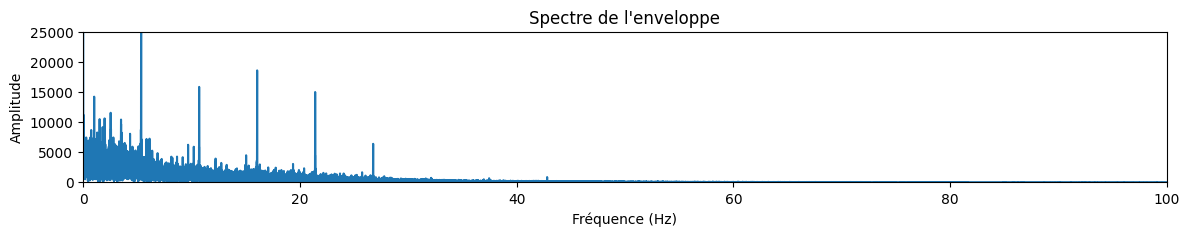

In [ ]:
from scipy.signal import hilbert

analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

# **Acc_2**

In [ ]:
id_channel = 5 # selection of the channel

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20648879, 7),
    (20648880, 23229989, 8),
    (23229990, 25811099, 9),
    (25811100, 28392209, 10),
    (28392210, 30973319, 11),
    (30973320, 32900556, 12)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés


In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


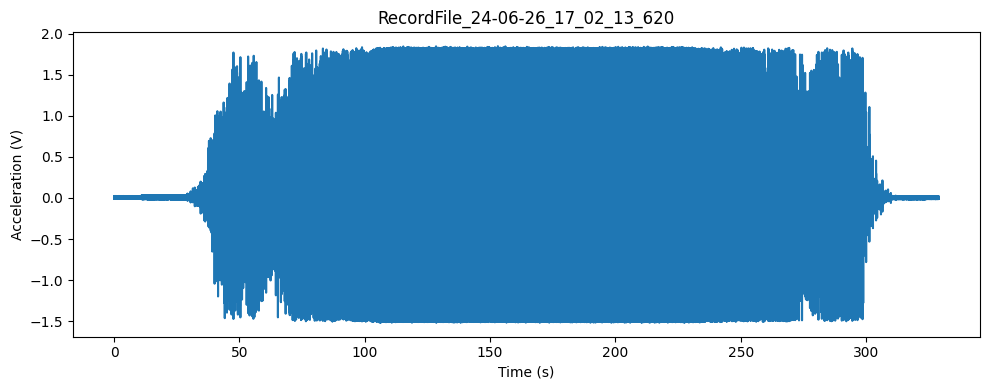

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

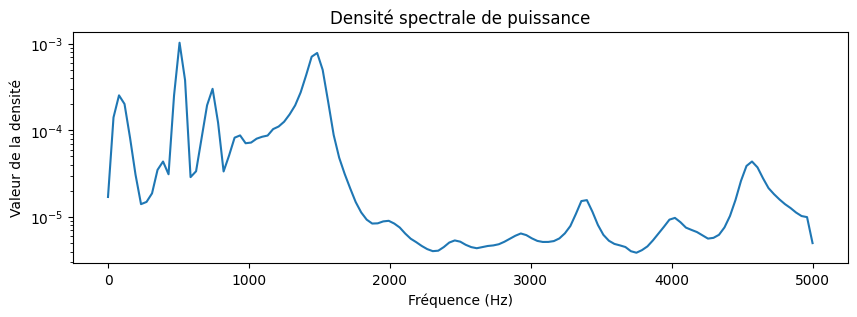

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

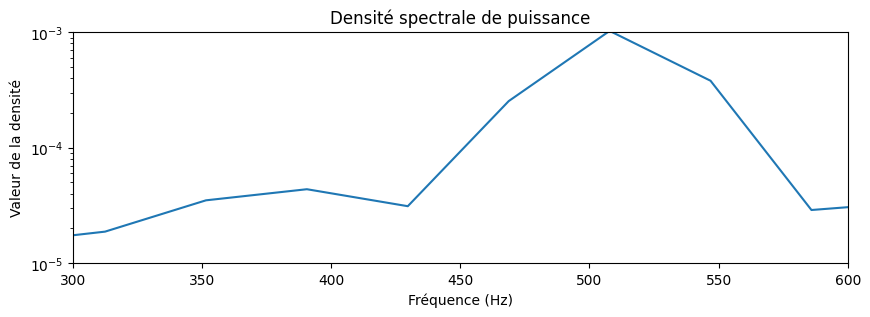

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(300, 600)
plt.ylim(1e-5, 1e-3)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 450   # Fréquence basse (Hz)
highcut = 550  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

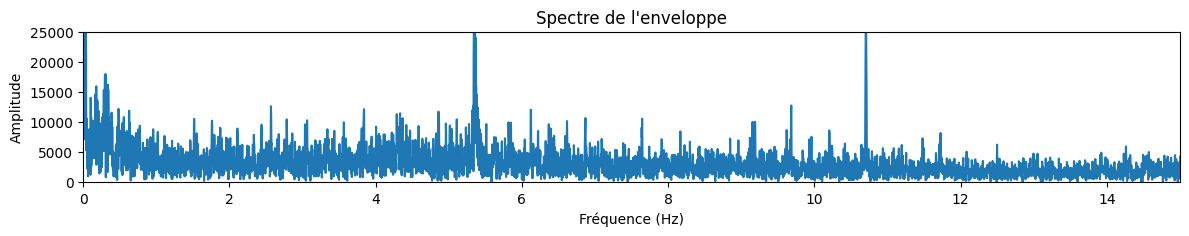

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 25000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

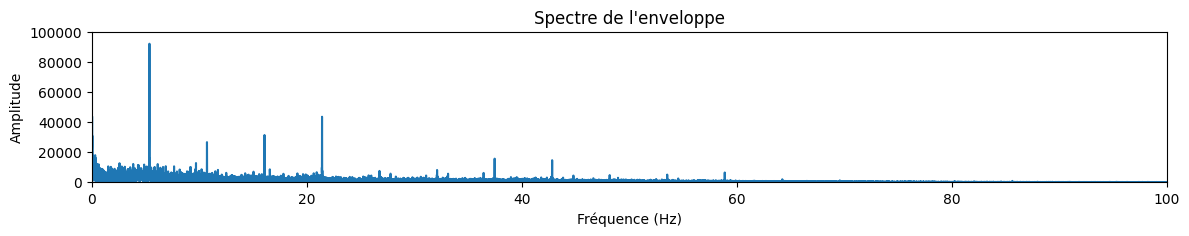

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 100000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

# **Acc_3**

In [ ]:
id_channel = 6 # selection of the channel

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20648879, 7),
    (20648880, 23229989, 8),
    (23229990, 25811099, 9),
    (25811100, 28392209, 10),
    (28392210, 30973319, 11),
    (30973320, 32900556, 12)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés


In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


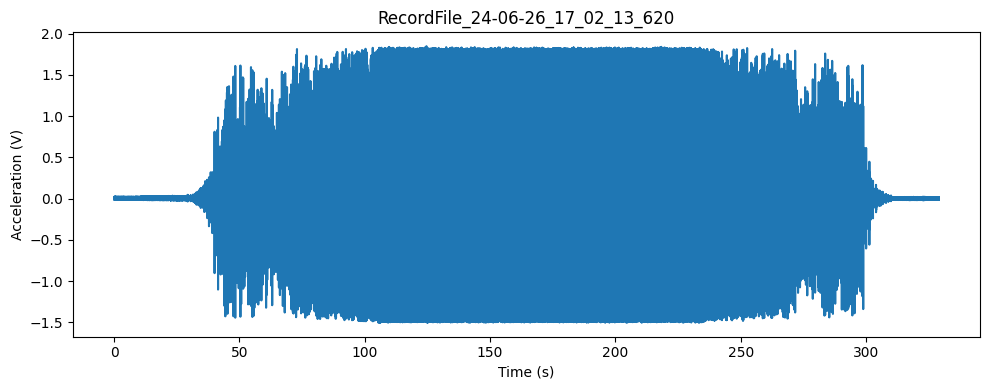

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

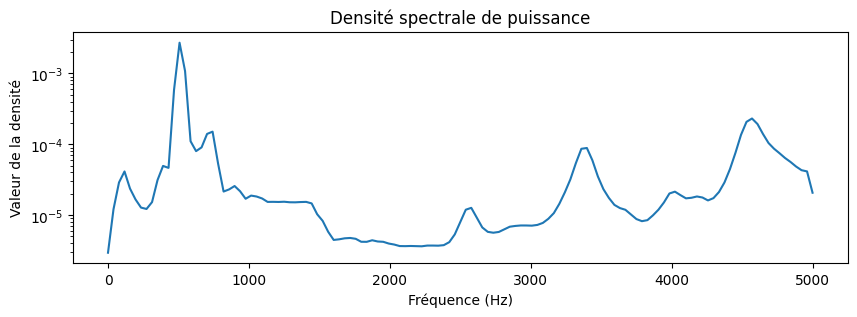

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

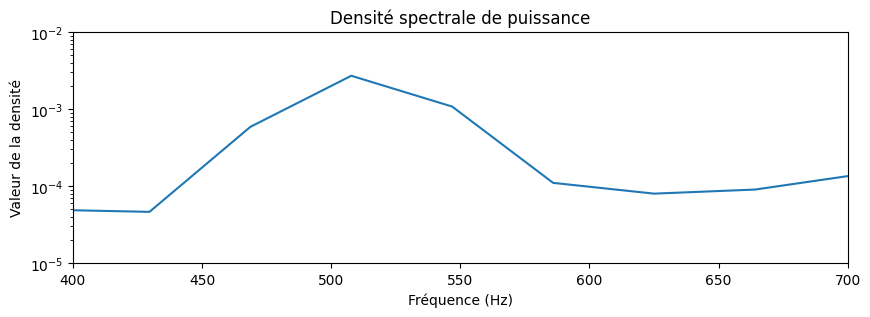

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(400, 700)
plt.ylim(1e-5, 1e-2)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 450   # Fréquence basse (Hz)
highcut = 550  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

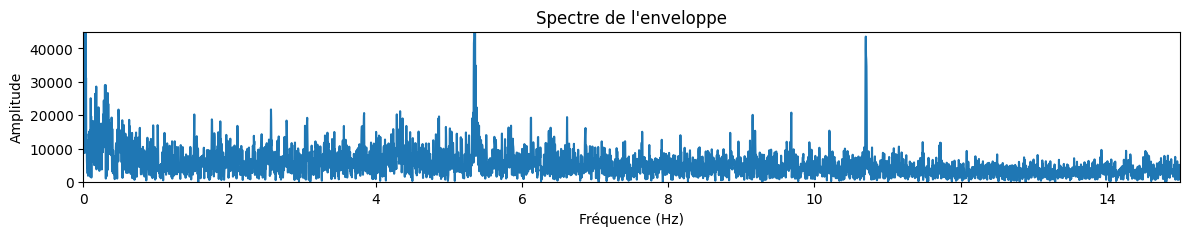

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 45000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

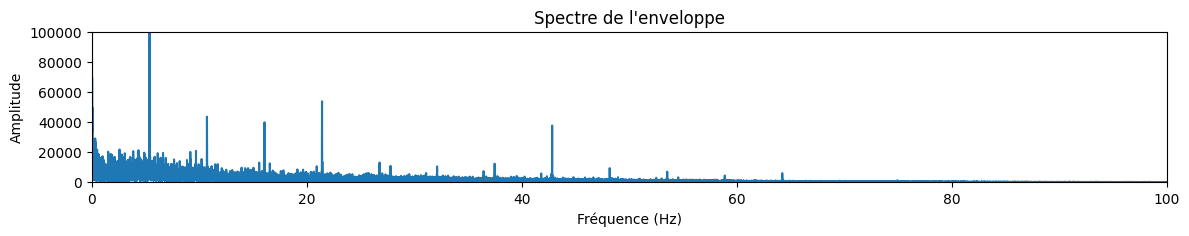

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 100000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

# **Acc_4**

In [ ]:
id_channel = 7 # selection of the channel

signal_id = l_signal_id[id_channel]

signal = data.get(signal_id)
#signal = data.filter([signal_id])
N = signal.samples.size
t = signal.timestamps
s = signal.samples

In [ ]:
# Définir les indices de début et de fin pour chaque segment
segments = [
    (0, 2581109, 0),
    (2581110, 5162219, 1),
    (5162220, 7743329, 2),
    (7743330, 10324439, 3),
    (10324440, 12905549, 4),
    (12905550, 15486659, 5),
    (15486660, 18067769, 6),
    (18067770, 20648879, 7),
    (20648880, 23229989, 8),
    (23229990, 25811099, 9),
    (25811100, 28392209, 10),
    (28392210, 30973319, 11),
    (30973320, 32900556, 12)
]

# Durée à ajouter pour chaque segment (en secondes)
time_increment = 25.811090000000004

# Correction de la liste t
t_corrected = t.copy()  # On part de la liste existante
for start, end, multiplier in segments:
    t_corrected[start:end + 1] = [x + multiplier * time_increment for x in t[start:end + 1]]

# La liste t_corrected contient maintenant les temps corrigés


In [ ]:
# Initialisation des variables
max_gap = 0
max_gap_indices = (None, None)  # Pour stocker les indices (i - 1, i) correspondant au plus grand écart

# Parcours de la liste pour calculer les écarts consécutifs
for i in range(1, len(t_corrected)):
    gap = t_corrected[i] - t_corrected[i - 1]  # Calcul de l'écart entre deux éléments consécutifs
    if gap > max_gap:  # Si l'écart est plus grand que l'écart maximum actuel
        max_gap = gap  # Mise à jour de l'écart maximum
        max_gap_indices = (i - 1, i)  # Mise à jour des indices correspondant à cet écart

# Affichage du résultat
print(f"L'écart maximum est : {max_gap}")
print(f"Indices correspondants : {max_gap_indices}")
print(f"Valeurs correspondantes : t_corrected[{max_gap_indices[0]}] = {t_corrected[max_gap_indices[0]]}, "
      f"t_corrected[{max_gap_indices[1]}] = {t_corrected[max_gap_indices[1]]}")


L'écart maximum est : 1.0000000031595846e-05
Indices correspondants : (12800049, 12800050)
Valeurs correspondantes : t_corrected[12800049] = 128.00045, t_corrected[12800050] = 128.00046000000003


In [ ]:
t = t_corrected[::10]
s = signal.samples[::10]
s -= np.mean(s)

Sampling frequency = 10000 Hz


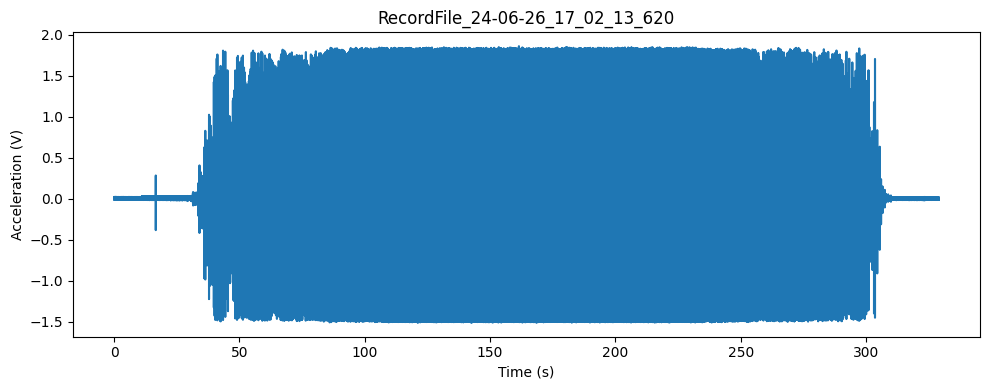

In [ ]:
fe = int(1/np.mean(np.diff(t)))
print(f"Sampling frequency = {fe} Hz")

plt.figure(figsize=(10,4))
if id_channel != 12:
    plt.plot(t, s)
else:
    sos = butter(4, 1, 'lowpass', fs=fe, output='sos')
    filtered = sosfilt(sos, s)
    plt.plot(t, s*160/6.6, alpha=0.25)
    plt.plot(t, filtered*160/6.6)
plt.xlabel('Time (s)')
if id_channel in [0,1,2,3]:
    plt.ylabel('Sound (V)')
elif id_channel in [4,5,6,7,8,9,10]:
    plt.ylabel('Acceleration (V)')
elif id_channel == 12:
    plt.ylabel('Speed (km/s)')
plt.title(name)
plt.tight_layout()
plt.show()

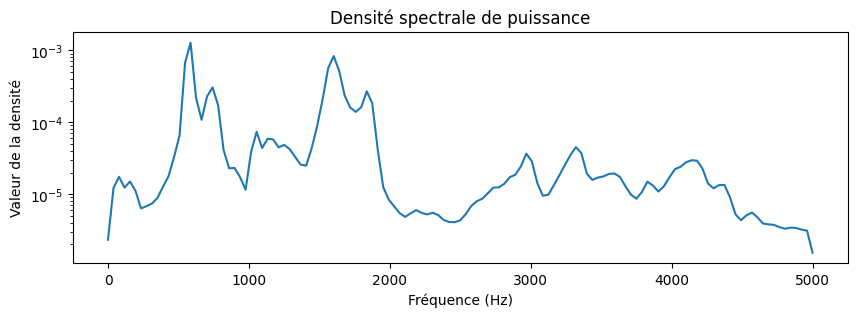

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

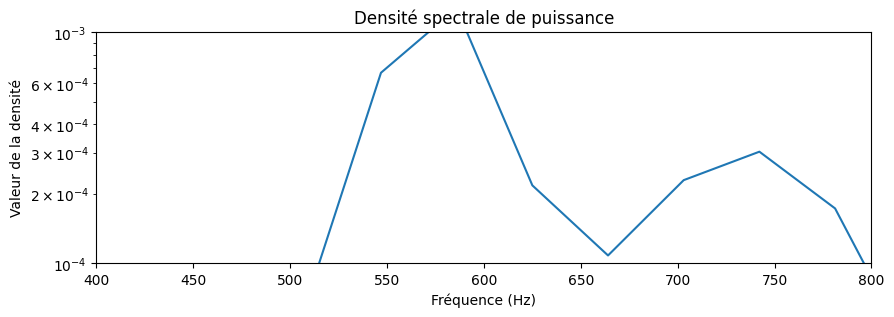

In [ ]:
x_f, Pxx_den = welch(s, fe, window='hann')
plt.figure(figsize=(10,3))
plt.semilogy(x_f, Pxx_den)
plt.xlim(400, 800)
plt.ylim(1e-4, 1e-3)
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Valeur de la densité')
plt.title('Densité spectrale de puissance')
plt.show()

In [ ]:
# Paramètres du filtre passe-bande
lowcut = 500   # Fréquence basse (Hz)
highcut = 600  # Fréquence haute (Hz)
fe = 10000      # Fréquence d'échantillonnage (Hz)

# Application du filtre
s -= np.mean(s)  # Recentrage du signal
filtered_signal = bandpass_filter(s, lowcut, highcut, fs=fe)

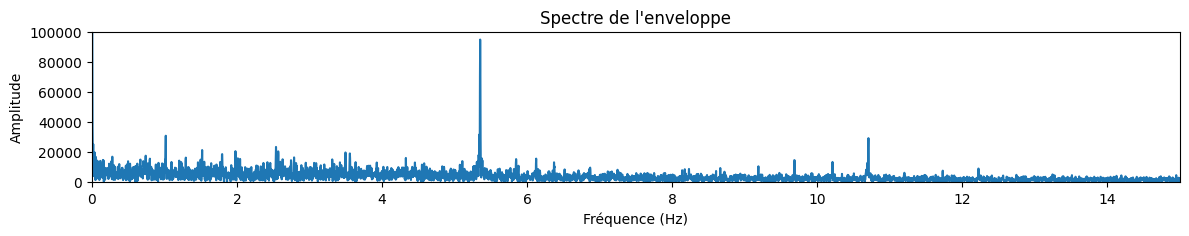

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 100000)
plt.xlim(0, 15)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

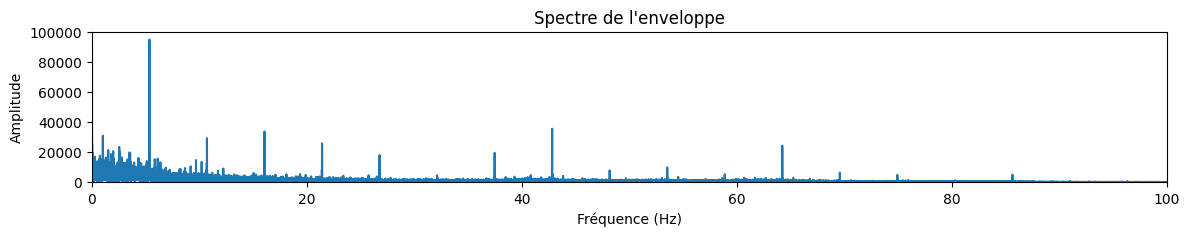

In [ ]:
analytic_signal = hilbert(filtered_signal)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 100000)
plt.xlim(0, 100)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()